# Visualizing CNN Predictions with LayerCAM

## Introduction
In this assignment, I investigate interpretability in a pretrained ResNet18 model using LayerCAM. 
I use three ImageNet classes: Persian cat, motor scooter, and space shuttle. And analyze both positive and negative examples for each class. 
For VG-level analysis, I also compare activations across multiple layers and include an out-of-distribution example.

## Method
I use a pretrained ResNet18 model with default ImageNet weights from torchvision. 
Images are preprocessed using the default transforms associated with the weights. 
LayerCAM is used to generate attribution maps, with layer4 as the default target layer for the main analysis. 
For the VG-level comparison, I also analyze layer1, layer2, and layer4.

In [4]:
from torchvision.models import get_model, get_model_weights
from functions import (load_image, get_prediction, topk_predictions, generate_cam, generate_overlay, analyze_image)

weights = get_model_weights("resnet18").DEFAULT
model = get_model("resnet18", weights = weights).eval()
preprocess = weights.transforms()

In [5]:
class_index_path = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Data/imagenet_class_index.json"

persian_cat_pos = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Data/persian_cat.jpg"
persian_cat_neg = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Data/tabby_cat.jpg"

motor_scooter_pos = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Data/motor_scooter.jpg"
motor_scooter_neg = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Data/bicycle.jpg"

space_shuttle_pos = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Data/space_shuttle.jpg"
space_shuttle_neg = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Data/plane.jpg"

ood_image = "C:/Users/samue/Documents/code/Machine-Learning-Samuel-Airisniemi/Labb2ny/Data/cartoon_cat.jpg"

Top 5 predictions:
{'class_index': 283, 'class_id': 'n02123394', 'class_name': 'Persian_cat', 'confidence': 0.6603424549102783}
{'class_index': 281, 'class_id': 'n02123045', 'class_name': 'tabby', 'confidence': 0.19179929792881012}
{'class_index': 282, 'class_id': 'n02123159', 'class_name': 'tiger_cat', 'confidence': 0.04546990990638733}
{'class_index': 287, 'class_id': 'n02127052', 'class_name': 'lynx', 'confidence': 0.04502291604876518}
{'class_index': 285, 'class_id': 'n02124075', 'class_name': 'Egyptian_cat', 'confidence': 0.01755281165242195}


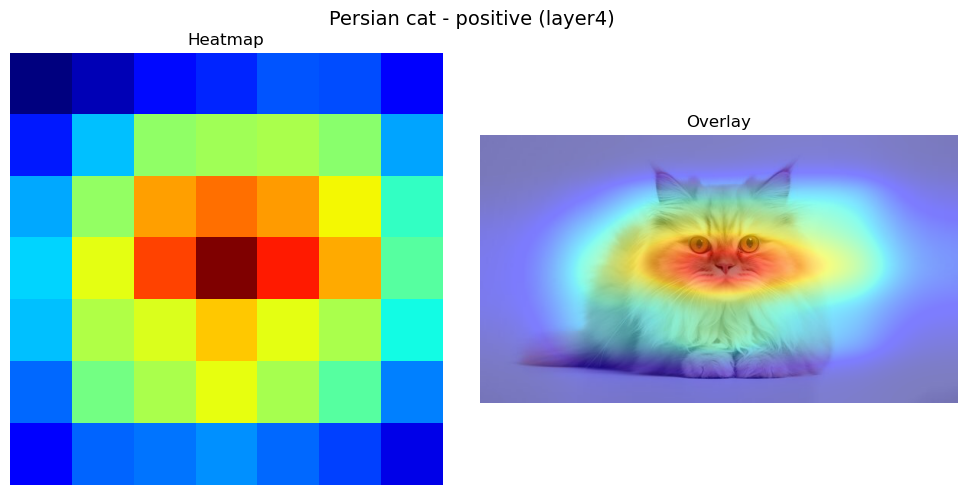

In [6]:
persian_cat_pos_result = analyze_image(model, preprocess, persian_cat_pos, class_index_path, "Persian cat - positive")

## Persian cat - Positive
The model correctly predicts the image as Persian cat with a confidence of 0.66. The remaining top-5 predictions are also cat-related classes such as tabby, tiger cat and Egyptian cat. This suggests that the model strongly identifies shared feline features, while still assigning the highest probability to Persian cat. The attribution map should therefore be interpreted as highlighting the regions that help the model distinguish this breed from other similar cats.

Top 5 predictions:
{'class_index': 281, 'class_id': 'n02123045', 'class_name': 'tabby', 'confidence': 0.8099306225776672}
{'class_index': 282, 'class_id': 'n02123159', 'class_name': 'tiger_cat', 'confidence': 0.1383843719959259}
{'class_index': 285, 'class_id': 'n02124075', 'class_name': 'Egyptian_cat', 'confidence': 0.04694410413503647}
{'class_index': 287, 'class_id': 'n02127052', 'class_name': 'lynx', 'confidence': 0.0011866107815876603}
{'class_index': 292, 'class_id': 'n02129604', 'class_name': 'tiger', 'confidence': 0.0006975671858526766}


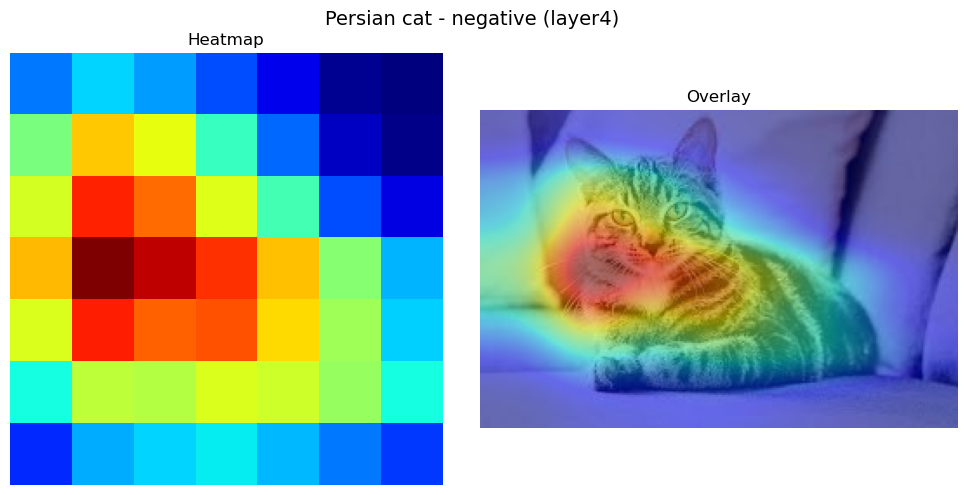

In [7]:
persian_cat_neg_result = analyze_image(model, preprocess, persian_cat_neg, class_index_path, "Persian cat - negative")

## Persian cat - Negative
For the negative example, the model predicts tabby with high confidence instead of Persian cat. This is a reasonable result, since the image still belongs to the broader category of cats. The top-5 predictions remain dominated by cat classes, which suggests that the model captures general cat features correctly but does not find enough evidence for the more specific Persian cat class.

Top 5 predictions:
{'class_index': 670, 'class_id': 'n03791053', 'class_name': 'motor_scooter', 'confidence': 0.8660216927528381}
{'class_index': 665, 'class_id': 'n03785016', 'class_name': 'moped', 'confidence': 0.13381743431091309}
{'class_index': 870, 'class_id': 'n04482393', 'class_name': 'tricycle', 'confidence': 9.042816236615181e-05}
{'class_index': 423, 'class_id': 'n02791124', 'class_name': 'barber_chair', 'confidence': 3.9080725400708616e-05}
{'class_index': 802, 'class_id': 'n04252077', 'class_name': 'snowmobile', 'confidence': 5.268928816803964e-06}


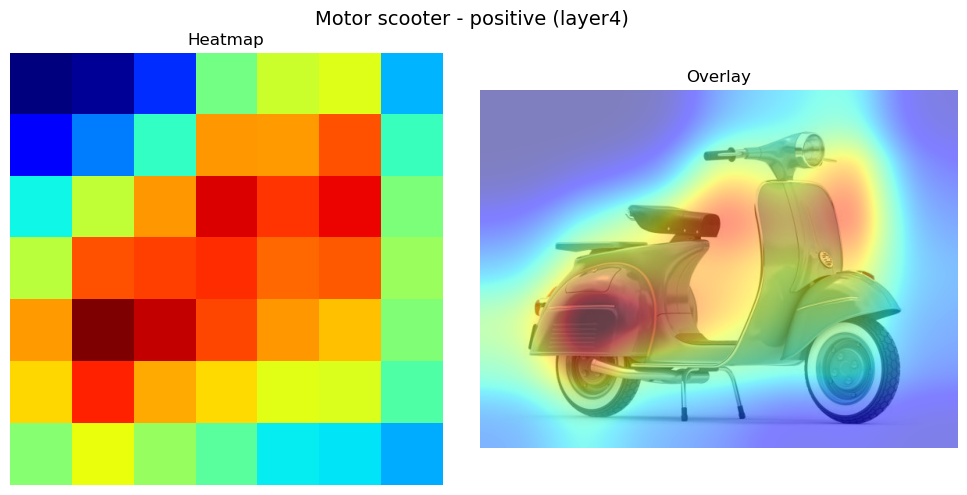

In [8]:
motor_scooter_pos_result = analyze_image(model, preprocess, motor_scooter_pos, class_index_path, "Motor scooter - positive")

## Motor scooter - Positive
The model correctly classifies the image as motor scooter with very high confidence. The second-ranked prediction is moped, which is visually similar. This indicates that the model has learned a coherent representation of small two-wheeled vehicles and is able to separate motor scooters from related transport categories.

Top 5 predictions:
{'class_index': 671, 'class_id': 'n03792782', 'class_name': 'mountain_bike', 'confidence': 0.6681833863258362}
{'class_index': 870, 'class_id': 'n04482393', 'class_name': 'tricycle', 'confidence': 0.17538222670555115}
{'class_index': 444, 'class_id': 'n02835271', 'class_name': 'bicycle-built-for-two', 'confidence': 0.10658977180719376}
{'class_index': 612, 'class_id': 'n03599486', 'class_name': 'jinrikisha', 'confidence': 0.015471884980797768}
{'class_index': 880, 'class_id': 'n04509417', 'class_name': 'unicycle', 'confidence': 0.013803288340568542}


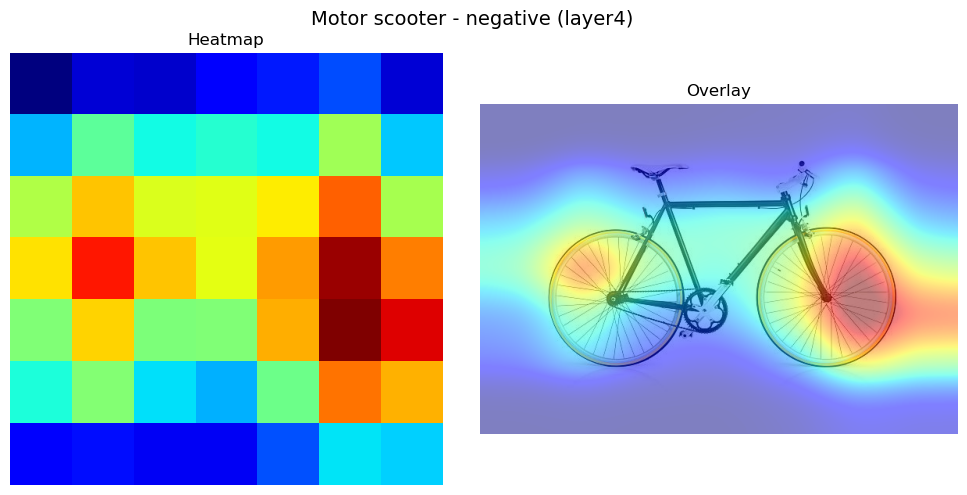

In [9]:
motor_scooter_neg_result = analyze_image(model, preprocess, motor_scooter_neg, class_index_path, "Motor scooter - negative")

## Motor scooter - Negative
In the negative example, the model predicts mountain bike rather than motor scooter. The rest of the top-5 predictions also belong to bicycle-like transport categories. This shows that the model is focusing on the overall geometry and wheel structure of the object, while correctly rejecting the motor scooter class.

Top 5 predictions:
{'class_index': 812, 'class_id': 'n04266014', 'class_name': 'space_shuttle', 'confidence': 0.5835702419281006}
{'class_index': 795, 'class_id': 'n04228054', 'class_name': 'ski', 'confidence': 0.1368766576051712}
{'class_index': 814, 'class_id': 'n04273569', 'class_name': 'speedboat', 'confidence': 0.11852975189685822}
{'class_index': 871, 'class_id': 'n04483307', 'class_name': 'trimaran', 'confidence': 0.039777230471372604}
{'class_index': 484, 'class_id': 'n02981792', 'class_name': 'catamaran', 'confidence': 0.020918451249599457}


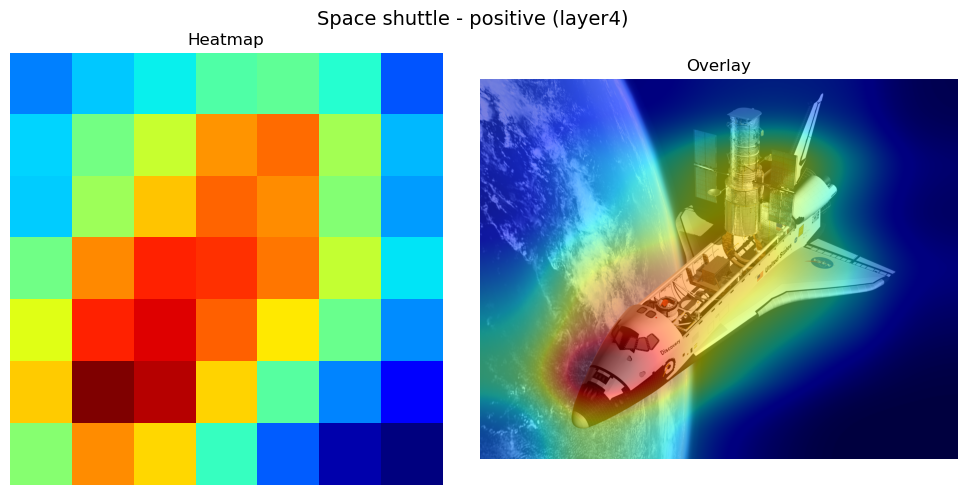

In [10]:
space_shuttle_pos_result = analyze_image(model, preprocess, space_shuttle_pos, class_index_path, "Space shuttle - positive")

## Space shuttle - Positive
The model predicts space shuttle correctly, but with lower confidence than in the cat and scooter examples. The alternative top-5 predictions include classes such as ski, speedboat and trimaran, which suggests that the model is partly relying on elongated shape and structural form rather than purely semantic understanding of spacecraft.

Top 5 predictions:
{'class_index': 404, 'class_id': 'n02690373', 'class_name': 'airliner', 'confidence': 0.7448831796646118}
{'class_index': 908, 'class_id': 'n04592741', 'class_name': 'wing', 'confidence': 0.17660126090049744}
{'class_index': 895, 'class_id': 'n04552348', 'class_name': 'warplane', 'confidence': 0.04434141889214516}
{'class_index': 744, 'class_id': 'n04008634', 'class_name': 'projectile', 'confidence': 0.010212687775492668}
{'class_index': 812, 'class_id': 'n04266014', 'class_name': 'space_shuttle', 'confidence': 0.009927944280207157}


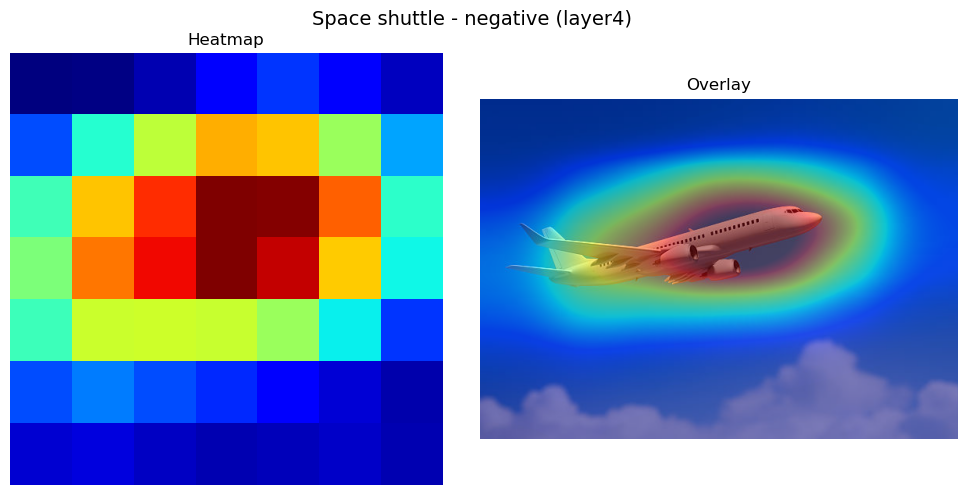

In [11]:
space_shuttle_neg_result = analyze_image(model, preprocess, space_shuttle_neg, class_index_path, "Space shuttle - negative")

## Space shuttle - Negative
For the negative example, the model predicts airliner with high confidence. Space shuttle still appears in the top-5, but only with a very small probability. This indicates that the model recognizes some shared flight-related visual patterns, but the evidence is much stronger for a standard aircraft.

Top 5 predictions:
{'class_index': 285, 'class_id': 'n02124075', 'class_name': 'Egyptian_cat', 'confidence': 0.25974562764167786}
{'class_index': 281, 'class_id': 'n02123045', 'class_name': 'tabby', 'confidence': 0.05485764518380165}
{'class_index': 761, 'class_id': 'n04074963', 'class_name': 'remote_control', 'confidence': 0.049362629652023315}
{'class_index': 453, 'class_id': 'n02870880', 'class_name': 'bookcase', 'confidence': 0.04398554563522339}
{'class_index': 620, 'class_id': 'n03642806', 'class_name': 'laptop', 'confidence': 0.03813491761684418}


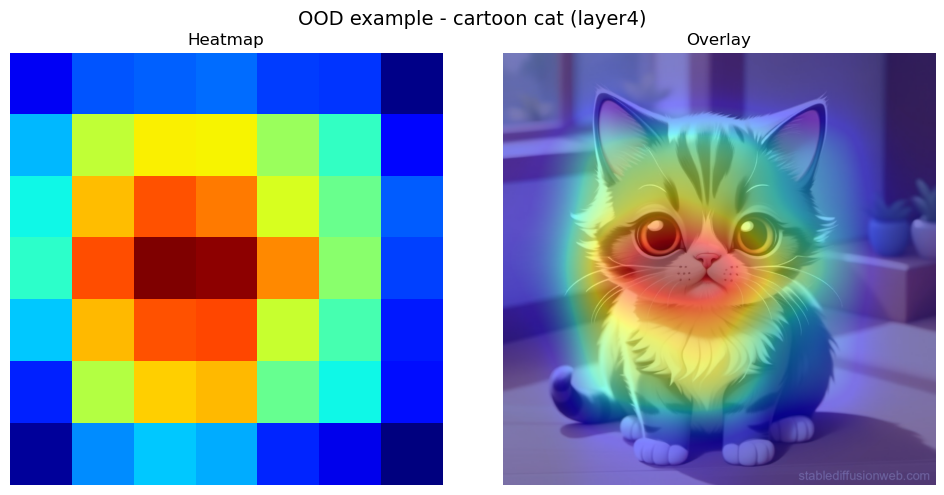

In [12]:
ood_result = analyze_image(model, preprocess, ood_image, class_index_path, "OOD example - cartoon cat")

## OOD - Cartoon cat
The cartoon cat is classified as Egyptian cat, but with low confidence. The rest of the top-5 predictions are mixed, including both cat-related and unrelated object classes. This suggests that the model attempts to match the cartoon image to the closest known natural-image category, but the stylized appearance causes uncertainty and weaker semantic alignment. Since the classifier is limited to the 1000 ImageNet categories, it cannot explicitly label the cartoon cat as “unknown”. Instead, it assigns the image to the closest familiar category, which in this case is a cat-related class.

Top 5 predictions:
{'class_index': 283, 'class_id': 'n02123394', 'class_name': 'Persian_cat', 'confidence': 0.6603424549102783}
{'class_index': 281, 'class_id': 'n02123045', 'class_name': 'tabby', 'confidence': 0.19179929792881012}
{'class_index': 282, 'class_id': 'n02123159', 'class_name': 'tiger_cat', 'confidence': 0.04546990990638733}
{'class_index': 287, 'class_id': 'n02127052', 'class_name': 'lynx', 'confidence': 0.04502291604876518}
{'class_index': 285, 'class_id': 'n02124075', 'class_name': 'Egyptian_cat', 'confidence': 0.01755281165242195}


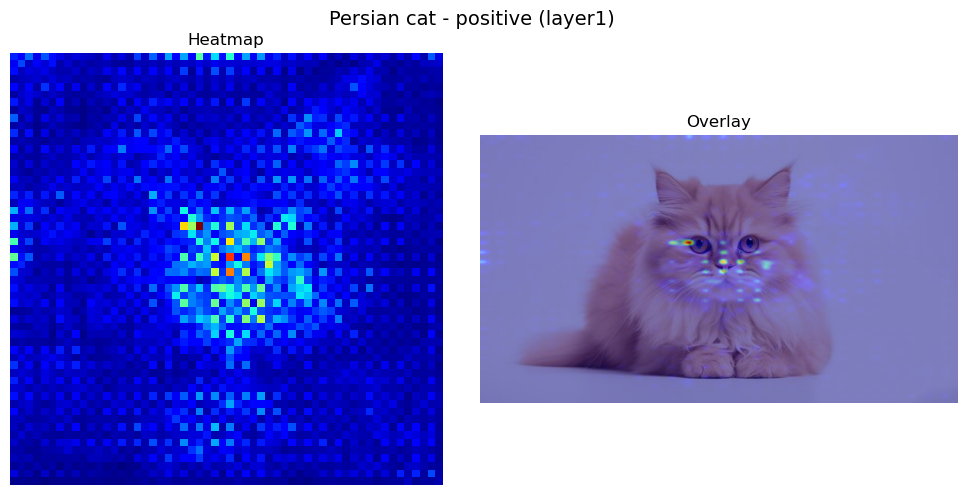

In [13]:
persian_cat_layer1 = analyze_image(model, preprocess, persian_cat_pos, class_index_path, "Persian cat - positive", target_layer="layer1")

Top 5 predictions:
{'class_index': 283, 'class_id': 'n02123394', 'class_name': 'Persian_cat', 'confidence': 0.6603424549102783}
{'class_index': 281, 'class_id': 'n02123045', 'class_name': 'tabby', 'confidence': 0.19179929792881012}
{'class_index': 282, 'class_id': 'n02123159', 'class_name': 'tiger_cat', 'confidence': 0.04546990990638733}
{'class_index': 287, 'class_id': 'n02127052', 'class_name': 'lynx', 'confidence': 0.04502291604876518}
{'class_index': 285, 'class_id': 'n02124075', 'class_name': 'Egyptian_cat', 'confidence': 0.01755281165242195}


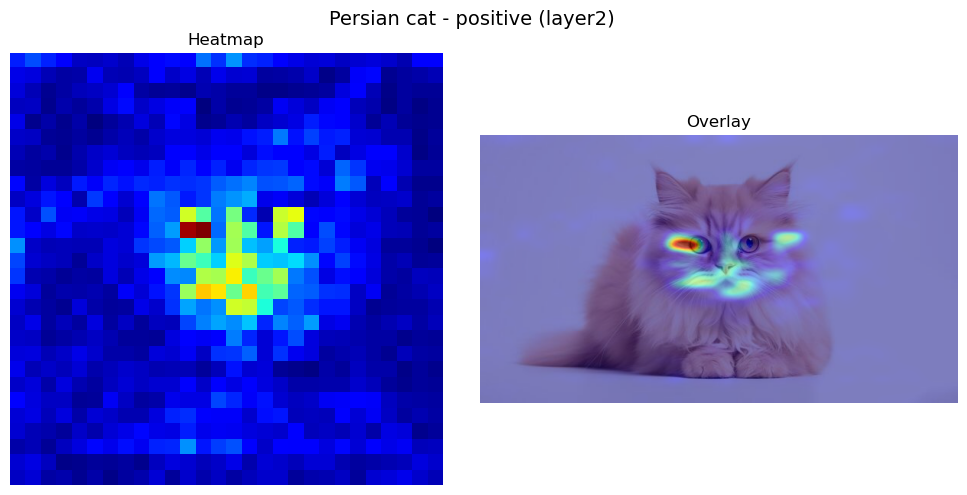

In [14]:
persian_cat_layer2 = analyze_image(model, preprocess, persian_cat_pos, class_index_path, "Persian cat - positive", target_layer="layer2")

Top 5 predictions:
{'class_index': 283, 'class_id': 'n02123394', 'class_name': 'Persian_cat', 'confidence': 0.6603424549102783}
{'class_index': 281, 'class_id': 'n02123045', 'class_name': 'tabby', 'confidence': 0.19179929792881012}
{'class_index': 282, 'class_id': 'n02123159', 'class_name': 'tiger_cat', 'confidence': 0.04546990990638733}
{'class_index': 287, 'class_id': 'n02127052', 'class_name': 'lynx', 'confidence': 0.04502291604876518}
{'class_index': 285, 'class_id': 'n02124075', 'class_name': 'Egyptian_cat', 'confidence': 0.01755281165242195}


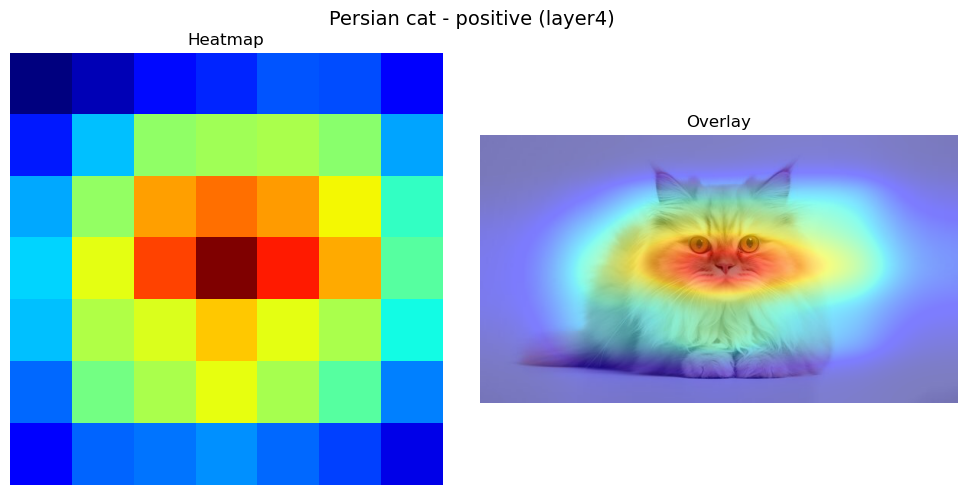

In [15]:
persian_cat_layer4 = analyze_image(model, preprocess, persian_cat_pos, class_index_path, "Persian cat - positive", target_layer="layer4")

## Persian cat - Layer comparison
In the early layer (layer1), the activation is broader and appears to follow low-level visual patterns such as fur texture, contrast, and edges around the cat’s face and body. In the middle layer (layer2), the activation becomes more concentrated on larger parts of the cat, especially the head and upper body. In the late layer (layer4), the attention is more focused on the most class-relevant regions, particularly the facial area and surrounding fur. This suggests that the network gradually moves from general visual features toward more class-specific evidence for identifying a Persian cat.

Top 5 predictions:
{'class_index': 670, 'class_id': 'n03791053', 'class_name': 'motor_scooter', 'confidence': 0.8660216927528381}
{'class_index': 665, 'class_id': 'n03785016', 'class_name': 'moped', 'confidence': 0.13381743431091309}
{'class_index': 870, 'class_id': 'n04482393', 'class_name': 'tricycle', 'confidence': 9.042816236615181e-05}
{'class_index': 423, 'class_id': 'n02791124', 'class_name': 'barber_chair', 'confidence': 3.9080725400708616e-05}
{'class_index': 802, 'class_id': 'n04252077', 'class_name': 'snowmobile', 'confidence': 5.268928816803964e-06}


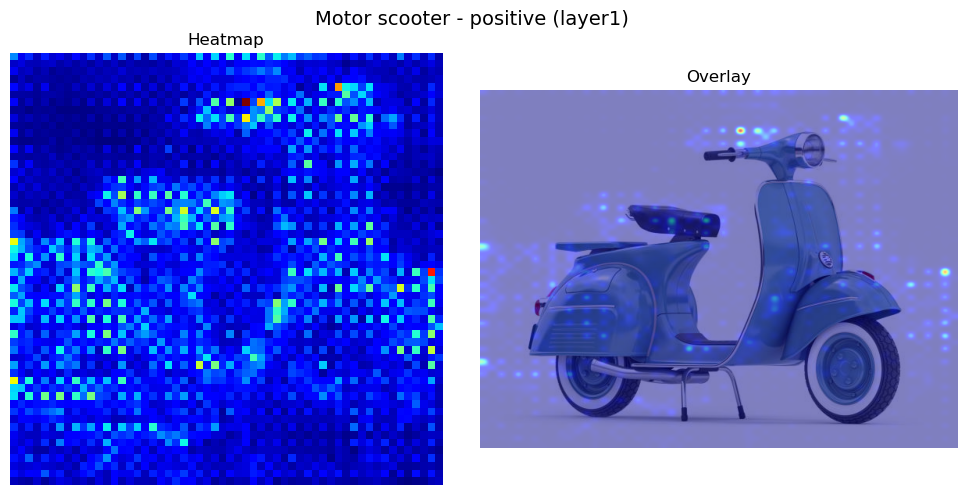

In [16]:
motor_scooter_layer1 = analyze_image(model, preprocess, motor_scooter_pos, class_index_path, "Motor scooter - positive", target_layer="layer1")

Top 5 predictions:
{'class_index': 670, 'class_id': 'n03791053', 'class_name': 'motor_scooter', 'confidence': 0.8660216927528381}
{'class_index': 665, 'class_id': 'n03785016', 'class_name': 'moped', 'confidence': 0.13381743431091309}
{'class_index': 870, 'class_id': 'n04482393', 'class_name': 'tricycle', 'confidence': 9.042816236615181e-05}
{'class_index': 423, 'class_id': 'n02791124', 'class_name': 'barber_chair', 'confidence': 3.9080725400708616e-05}
{'class_index': 802, 'class_id': 'n04252077', 'class_name': 'snowmobile', 'confidence': 5.268928816803964e-06}


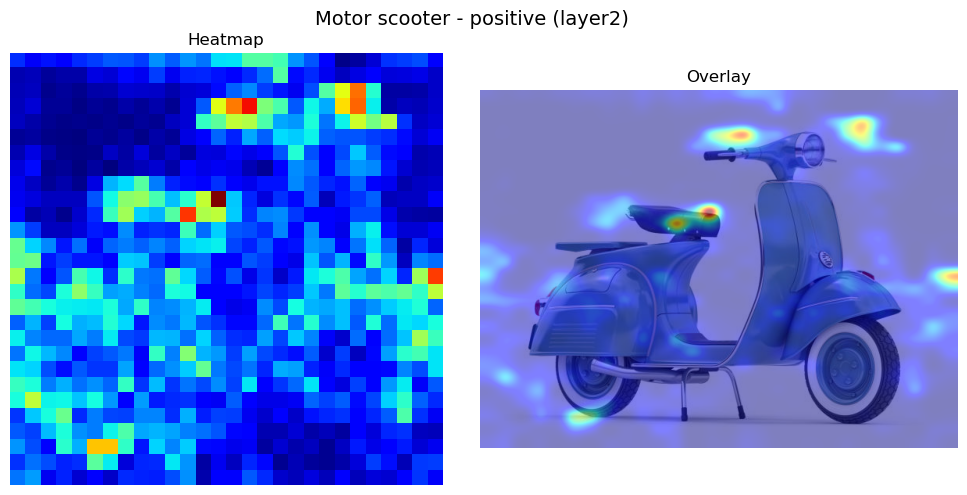

In [17]:
motor_scooter_layer2 = analyze_image(model, preprocess, motor_scooter_pos, class_index_path, "Motor scooter - positive", target_layer="layer2")

Top 5 predictions:
{'class_index': 670, 'class_id': 'n03791053', 'class_name': 'motor_scooter', 'confidence': 0.8660216927528381}
{'class_index': 665, 'class_id': 'n03785016', 'class_name': 'moped', 'confidence': 0.13381743431091309}
{'class_index': 870, 'class_id': 'n04482393', 'class_name': 'tricycle', 'confidence': 9.042816236615181e-05}
{'class_index': 423, 'class_id': 'n02791124', 'class_name': 'barber_chair', 'confidence': 3.9080725400708616e-05}
{'class_index': 802, 'class_id': 'n04252077', 'class_name': 'snowmobile', 'confidence': 5.268928816803964e-06}


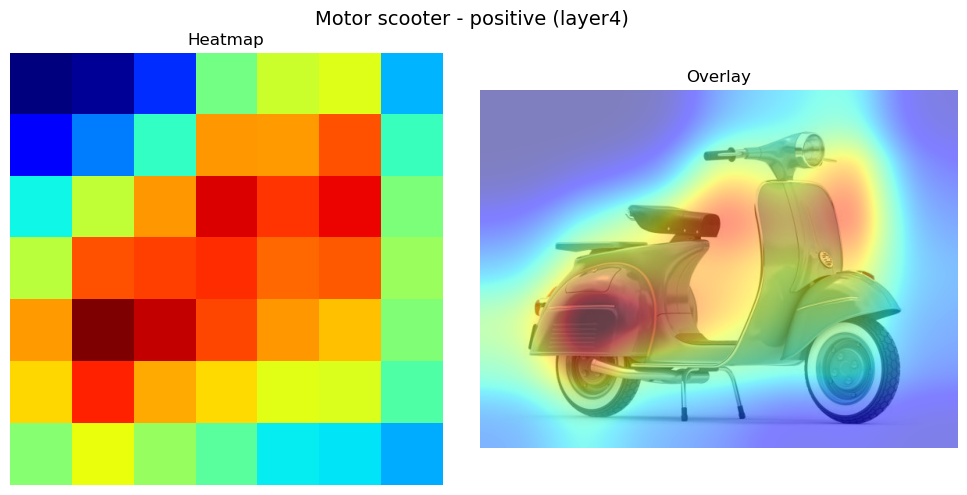

In [18]:
motor_scooter_layer4 = analyze_image(model, preprocess, motor_scooter_pos, class_index_path, "Motor scooter - positive", target_layer="layer4")

## Motor scooter - Layer comparison
For the motor scooter image, the early layer (layer1) seems to respond mainly to basic contours, wheels, and strong edges in the object. In the middle layer (layer2), the activation becomes more structured around recognizable scooter components such as the seat, steering area, and wheel region. In the late layer (layer4), the heatmap is more concentrated on the parts of the object that appear most informative for distinguishing a motor scooter from similar transport categories. This progression is consistent with the idea that deeper layers encode more task-specific and semantically meaningful representations.

## Conclusion
Overall, the results show that LayerCAM provides useful insight into which image regions influence the model’s predictions. For the positive examples, the model generally focused on meaningful and class-relevant parts of the objects, while the negative examples showed that the network often still captured broader category-level similarities, such as cat-related or vehicle-related features. The layer comparison further suggested that early layers respond to simple visual patterns, whereas later layers focus more strongly on class-specific evidence. Finally, the out-of-distribution example demonstrated an important limitation: when presented with a stylized image outside the training distribution, the model still attempts to map it to the closest known ImageNet class.